In [1]:
import random as rd
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
# Download latest version
path = kagglehub.dataset_download("aiexplorer77/academic-performance-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\guwah\.cache\kagglehub\datasets\aiexplorer77\academic-performance-prediction\versions\1


In [3]:
import os
file_name = os.listdir(path)

In [4]:
file_name = file_name[0]

In [5]:
file_name

'student_performance_dataset.csv'

In [6]:
csv_file = os.path.join(path, file_name)
data = pd.read_csv(csv_file)
data.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

In [8]:
data.describe()

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000,3000.000000,3000.000000,...,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,19.030333,3.988767,3.511667,69.926333,74.558000,2.949422,0.493000,61.961667,1.538933,...,3.500333,1.054167,5.552000,5.467667,5.556667,5.546333,5.446000,5.535000,5.512333,54.795667
std,866.169729,2.553217,1.503377,2.297743,17.562794,14.473048,1.510306,0.500034,33.125156,0.925619,...,2.274436,0.725919,2.906564,2.856047,2.865809,2.864132,2.890421,2.837157,2.860287,18.691309
min,0.000000,15.000000,0.500000,0.000000,40.000000,50.000000,0.000000,0.000000,5.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,749.750000,17.000000,2.900000,1.000000,55.000000,62.000000,1.900000,0.000000,32.000000,0.900000,...,2.000000,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,42.000000
50%,1499.500000,19.000000,4.000000,4.000000,70.000000,74.000000,2.900000,0.000000,62.000000,1.500000,...,3.000000,1.000000,6.000000,5.000000,6.000000,6.000000,5.000000,6.000000,6.000000,55.000000
75%,2249.250000,21.000000,5.000000,6.000000,85.000000,87.000000,4.000000,1.000000,91.000000,2.100000,...,5.000000,1.600000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,67.000000
max,2999.000000,23.000000,8.800000,7.000000,100.000000,100.000000,8.900000,1.000000,119.000000,5.000000,...,7.000000,3.900000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,100.000000


In [9]:
data.isnull().sum()

student_id                      0
age                             0
gender                          0
city_type                       0
study_hours_per_day             0
deep_work_sessions              0
assignment_completion_rate      0
attendance_percentage           0
social_media_hours             60
doomscrolling_before_sleep      0
notification_distractions       0
ai_tool_usage_hours             0
gaming_hours                    0
stress_level                    0
motivation_level                0
focus_score                    60
procrastination_index           0
mental_state                    0
sleep_hours                    60
caffeine_intake                 0
physical_activity_hours         0
internet_quality                0
family_support                  0
financial_stress                0
learning_style                  0
career_goal                     0
productivity_after_midnight     0
revision_efficiency             0
burnout_risk                    0
consistency_sc

In [10]:
np.mean(data['social_media_hours'])

2.9494217687074826

In [11]:
# social_media_hours, focus_score, sleep_hours
data['social_media_hours'] = data['social_media_hours'].fillna(
    round(
        rd.uniform(
            np.mean(data['social_media_hours']) - 0.5,
            np.mean(data['social_media_hours']) + 0.5
        ),
        1
    )
)

In [12]:
np.mean(data['focus_score'])

5.51156462585034

In [13]:
# social_media_hours, focus_score, sleep_hours
data['focus_score'] = data['focus_score'].fillna(
    round(
        rd.uniform(
            np.mean(data['focus_score']) - 1,
            np.mean(data['focus_score']) + 1
        ),
        1
    )
)

In [14]:
np.mean(data['sleep_hours'])

6.510306122448981

In [15]:
# social_media_hours, focus_score, sleep_hours
data['sleep_hours'] = data['sleep_hours'].fillna(
    round(
        rd.uniform(
            np.mean(data['sleep_hours']) - 1.5,
            np.mean(data['sleep_hours']) + 1.5
        ),
        1
    )
)

In [16]:
data = data.drop_duplicates()

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           3000 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level      

### So No duplicate is there :

In [18]:
# As the Student id is not important For prediction of model

In [19]:
data['city_type'].unique()

array(['Semi-Urban', 'Urban', 'Rural'], dtype=object)

In [20]:
data['mental_state'].unique()

array(['Balanced', 'Burnout', 'Focused', 'Distracted'], dtype=object)

In [21]:
data['learning_style'].unique()

array(['Audio', 'Practical', 'Visual', 'Reading'], dtype=object)

In [22]:
data['career_goal'].unique()

array(['Engineering', 'Business', 'Medical', 'Arts', 'Research'],
      dtype=object)

In [23]:
data['performance_category'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [24]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
encoded = encoder.fit_transform(data[['gender','city_type', 'mental_state', 'learning_style', 'career_goal']])

In [25]:
data

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2995,22,Female,Rural,2.4,0,40,83,1.0,0,...,10,2,Practical,Arts,9,10,7,9,45,Low
2996,2996,19,Female,Urban,5.2,7,94,100,1.4,0,...,1,10,Visual,Medical,5,3,7,9,100,High
2997,2997,23,Female,Rural,5.9,2,41,86,5.4,1,...,7,10,Practical,Engineering,6,8,10,10,50,Medium
2998,2998,17,Male,Urban,3.9,1,92,96,2.8,1,...,3,10,Practical,Medical,4,7,1,4,76,High


In [26]:
Data_X = data.iloc[:,:-1]
Data_y = data.iloc[:,-1:]

In [27]:
Data_X.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,internet_quality,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,1,10,6,Audio,Engineering,9,1,10,3,32
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,4,2,6,Practical,Business,6,10,4,6,59
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,9,1,9,Visual,Engineering,7,9,8,1,34
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,1,5,10,Reading,Medical,7,7,9,10,60
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,9,5,6,Visual,Medical,4,10,7,9,77


In [28]:
print(encoded.toarray())

[[1. 0. 0. ... 1. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 1. 0. 0.]
 ...
 [1. 0. 1. ... 1. 0. 0.]
 [0. 1. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


In [29]:
import pandas as pd

encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=encoder.get_feature_names_out(['gender','city_type', 'mental_state', 'learning_style', 'career_goal'])
)

encoded_df

,gender_Female,gender_Male,city_type_Rural,city_type_Semi-Urban,city_type_Urban,mental_state_Balanced,mental_state_Burnout,mental_state_Distracted,mental_state_Focused,learning_style_Audio,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Arts,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2996,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2997,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2998,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [30]:
Data_X1 = pd.concat([Data_X,encoded_df], axis=1)
Data_X1 = Data_X1.drop(columns=['gender','city_type', 'mental_state', 'learning_style', 'career_goal'])
Data_X1.head()

,student_id,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,...,mental_state_Focused,learning_style_Audio,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Arts,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research
0,0,21,3.2,7,100,70,3.8,0,107,0.6,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,19,3.9,2,46,70,2.6,1,93,1.5,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2,16,4.3,7,54,57,4.3,1,82,0.5,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,3,19,5.3,1,78,90,1.7,0,27,1.4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,17,4.1,3,100,81,2.6,0,8,1.3,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [31]:
Data_y.head()

,performance_category
0,Low
1,Medium
2,Low
3,Medium
4,High


In [32]:
Data_X1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   study_hours_per_day          3000 non-null   float64
 3   deep_work_sessions           3000 non-null   int64  
 4   assignment_completion_rate   3000 non-null   int64  
 5   attendance_percentage        3000 non-null   int64  
 6   social_media_hours           3000 non-null   float64
 7   doomscrolling_before_sleep   3000 non-null   int64  
 8   notification_distractions    3000 non-null   int64  
 9   ai_tool_usage_hours          3000 non-null   float64
 10  gaming_hours                 3000 non-null   float64
 11  stress_level                 3000 non-null   int64  
 12  motivation_level             3000 non-null   int64  
 13  focus_score       

In [33]:
Data_X1.isnull().sum()

student_id                     0
age                            0
study_hours_per_day            0
deep_work_sessions             0
assignment_completion_rate     0
attendance_percentage          0
social_media_hours             0
doomscrolling_before_sleep     0
notification_distractions      0
ai_tool_usage_hours            0
gaming_hours                   0
stress_level                   0
motivation_level               0
focus_score                    0
procrastination_index          0
sleep_hours                    0
caffeine_intake                0
physical_activity_hours        0
internet_quality               0
family_support                 0
financial_stress               0
productivity_after_midnight    0
revision_efficiency            0
burnout_risk                   0
consistency_score              0
final_exam_score               0
gender_Female                  0
gender_Male                    0
city_type_Rural                0
city_type_Semi-Urban           0
city_type_

In [34]:
Data_X1 = Data_X1.drop(columns='student_id')
Data_X1.head()

,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,...,mental_state_Focused,learning_style_Audio,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Arts,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research
0,21,3.2,7,100,70,3.8,0,107,0.6,1.8,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,19,3.9,2,46,70,2.6,1,93,1.5,1.1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,16,4.3,7,54,57,4.3,1,82,0.5,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,19,5.3,1,78,90,1.7,0,27,1.4,3.8,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,17,4.1,3,100,81,2.6,0,8,1.3,2.5,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [35]:
corr_matric = Data_X1.corr(numeric_only=True) 
corr_matric

,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,...,mental_state_Focused,learning_style_Audio,learning_style_Practical,learning_style_Reading,learning_style_Visual,career_goal_Arts,career_goal_Business,career_goal_Engineering,career_goal_Medical,career_goal_Research
age,1.000000,-0.005097,0.016621,-0.026400,0.001789,-0.004685,-0.010150,-0.019041,-0.038637,0.023887,...,0.010784,-0.010665,0.034510,-0.031686,0.007174,-0.003186,0.007049,0.020684,0.008300,-0.033344
study_hours_per_day,-0.005097,1.000000,-0.023192,-0.009388,0.005088,-0.007084,-0.031398,-0.009896,-0.001972,0.011686,...,-0.013432,0.019040,0.002365,-0.001182,-0.019704,-0.013231,-0.001325,-0.005823,0.023236,-0.003195
deep_work_sessions,0.016621,-0.023192,1.000000,-0.017938,-0.034397,-0.028805,-0.015891,-0.004798,0.034074,-0.008715,...,-0.020919,-0.018976,0.021729,0.005736,-0.008635,-0.005640,-0.009096,0.033210,-0.009030,-0.009296
assignment_completion_rate,-0.026400,-0.009388,-0.017938,1.000000,-0.004436,0.007512,0.004441,0.019573,-0.000135,-0.002601,...,0.005174,-0.011040,-0.001572,-0.008275,0.020372,-0.028177,0.024093,-0.007745,0.013768,-0.001583
attendance_percentage,0.001789,0.005088,-0.034397,-0.004436,1.000000,-0.006726,-0.012039,0.013282,0.021479,0.000001,...,0.020082,0.029492,0.039613,-0.035785,-0.032929,-0.013097,-0.027481,0.000038,0.008735,0.032070
social_media_hours,-0.004685,-0.007084,-0.028805,0.007512,-0.006726,1.000000,0.003272,0.002364,-0.010104,0.015697,...,-0.036651,0.014497,-0.013451,0.014734,-0.015181,0.012672,0.009189,-0.028963,0.033797,-0.028016
doomscrolling_before_sleep,-0.010150,-0.031398,-0.015891,0.004441,-0.012039,0.003272,1.000000,0.020890,-0.028300,-0.020859,...,0.008778,0.019582,0.002024,-0.006807,-0.014401,0.001415,0.027102,-0.029914,-0.007513,0.009347
notification_distractions,-0.019041,-0.009896,-0.004798,0.019573,0.013282,0.002364,0.020890,1.000000,0.004092,-0.005128,...,-0.004127,0.015478,0.007431,0.005791,-0.028058,0.008557,-0.002945,-0.015661,-0.008348,0.018639
ai_tool_usage_hours,-0.038637,-0.001972,0.034074,-0.000135,0.021479,-0.010104,-0.028300,0.004092,1.000000,-0.022460,...,-0.021627,0.012002,-0.002393,-0.012384,0.002784,-0.004933,-0.005883,-0.015339,0.016423,0.009521
gaming_hours,0.023887,0.011686,-0.008715,-0.002601,0.000001,0.015697,-0.020859,-0.005128,-0.022460,1.000000,...,0.008588,0.024312,-0.001126,-0.014943,-0.007945,0.001012,0.020433,-0.016330,-0.008836,0.004090


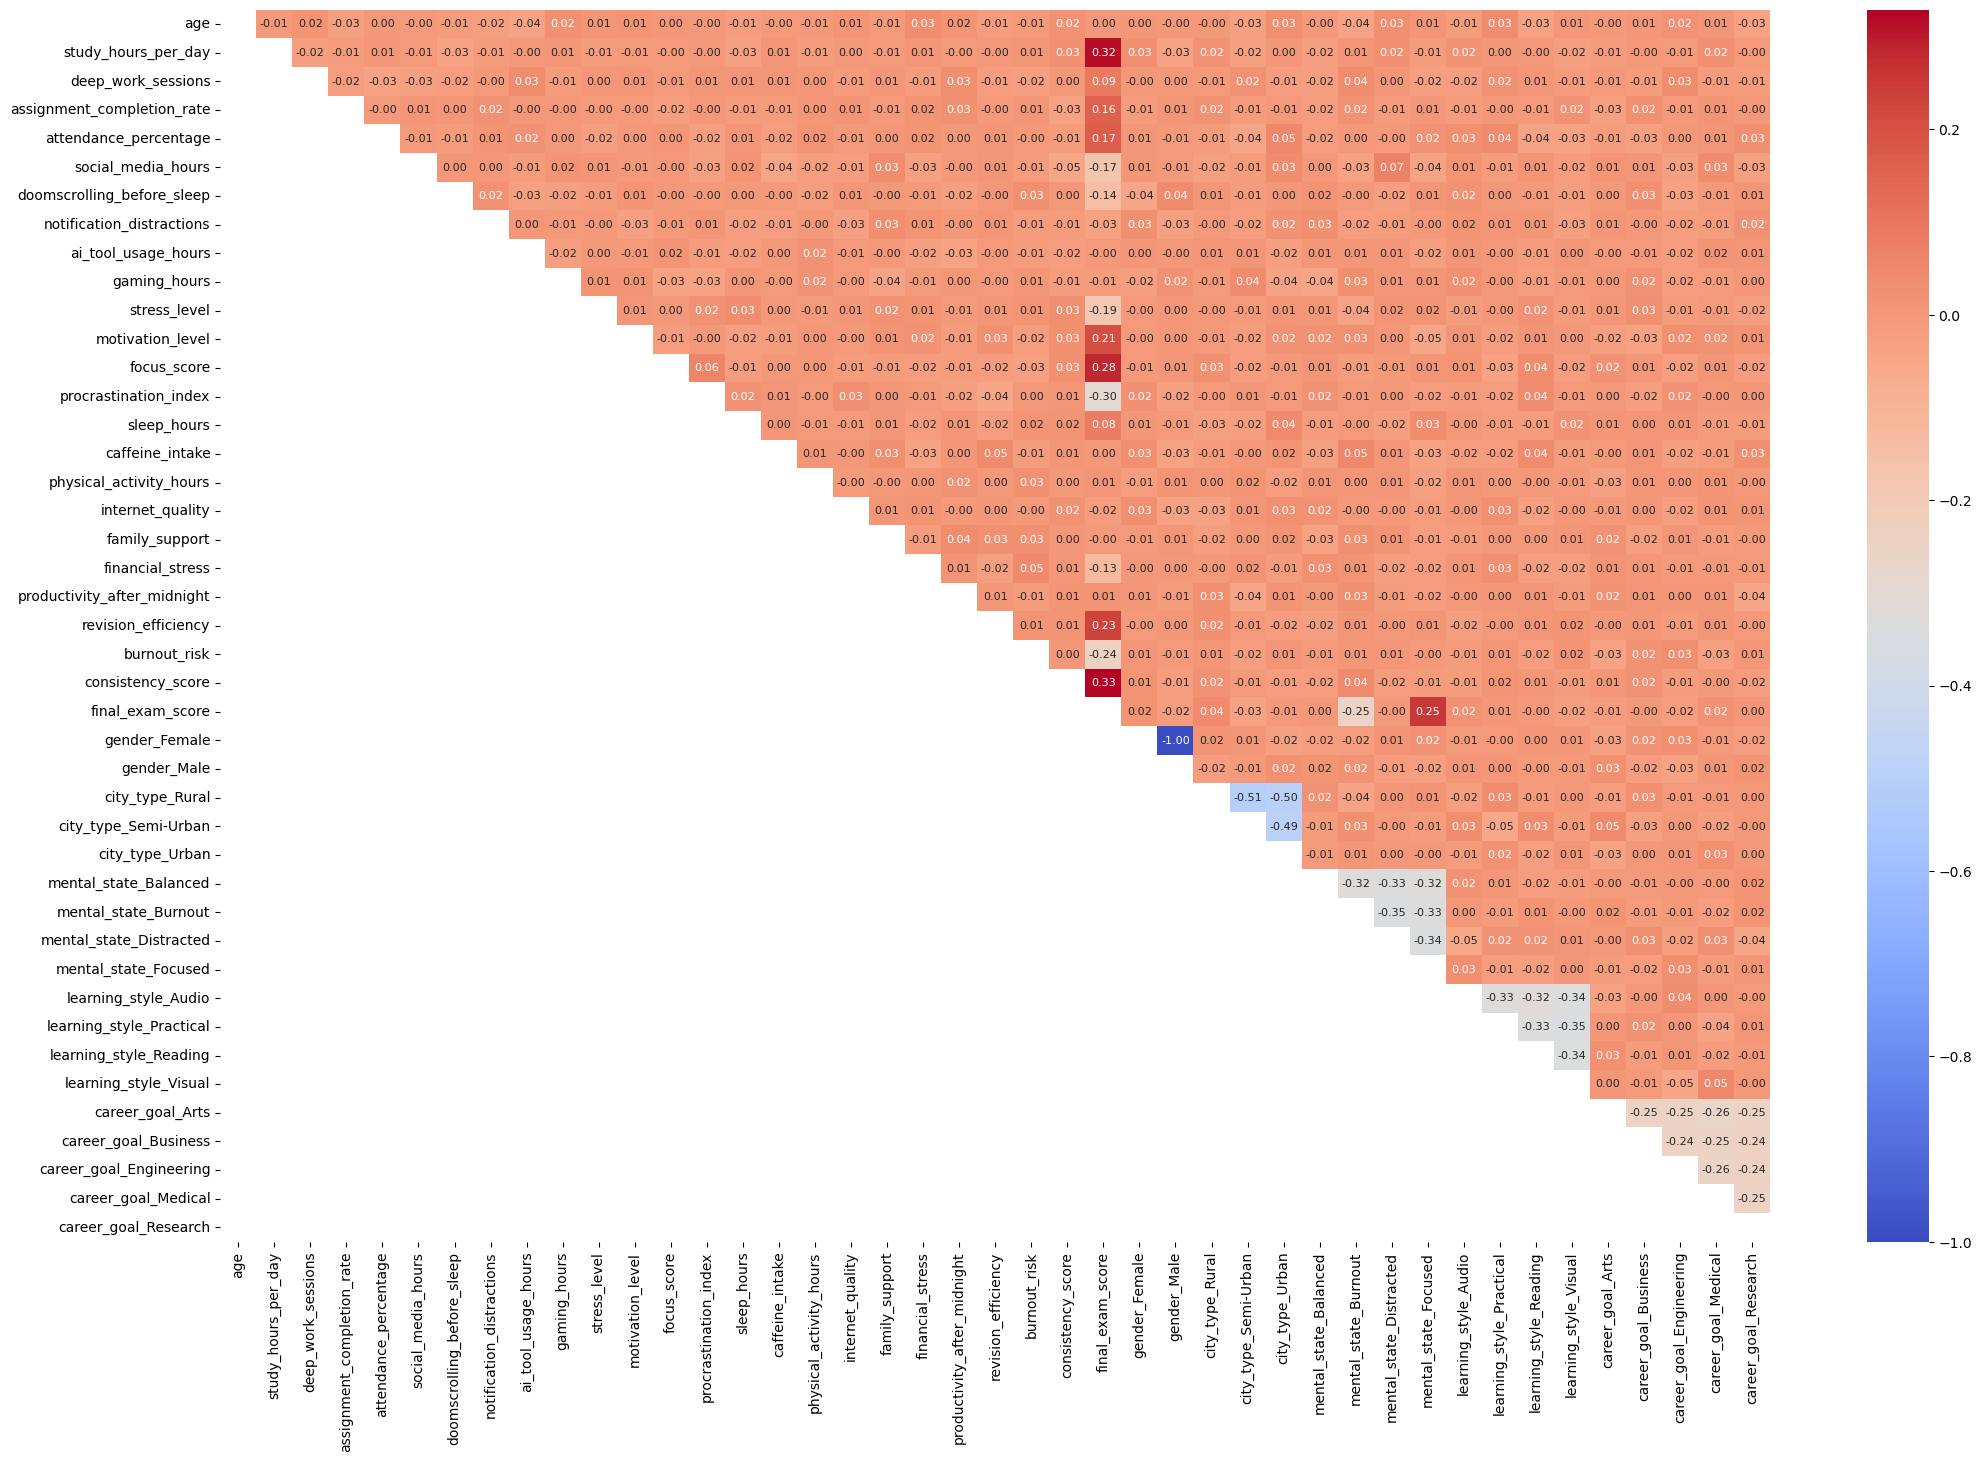

In [36]:
# Create mask for lower triangle
mask = np.tril(np.ones_like(corr_matric, dtype=bool))

plt.figure(figsize=(25,16))

sns.heatmap(
    corr_matric,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size":8},
    cmap="coolwarm"
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

## After Plotting the Coverience Matrix I obserbed that no are the that much realted to drop that features . So no Multicoliniarity Concept Here now 

In [38]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [70]:
X_train, X_test, y_train, y_test = train_test_split(Data_X1,Data_y,test_size=0.2, random_state=42)

In [71]:
# Encode the Data of Data_y using label encoder :
mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

y_train['performance_category'] = y_train['performance_category'].map(mapping)
y_test['performance_category'] = y_test['performance_category'].map(mapping)

In [72]:
y_train.head()

,performance_category
642,1
700,2
226,0
1697,2
1010,0


In [73]:
y_test.head()

,performance_category
1801,0
1190,1
1817,1
251,1
2505,0


In [74]:
y_train = y_train['performance_category']
y_test = y_test['performance_category']

In [76]:
y_train = y_train.to_numpy()

In [77]:
y_train

array([1, 2, 0, ..., 1, 0, 2], dtype=int64)

In [78]:
y_test = y_test.to_numpy()

In [79]:
y_test

array([0, 1, 1, 1, 0, 1, 2, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 2, 1, 0,
       1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 2, 1, 2, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 0, 2, 1, 1, 1, 1, 1, 0, 0, 2, 2,
       1, 1, 0, 1, 2, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 2, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 2, 1, 1, 1, 0, 1,
       0, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 2, 0, 0, 1, 2, 2, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 2, 1, 0, 0, 2, 1, 1, 1, 0, 1, 2, 1, 1, 0, 1, 1, 2, 0, 1, 2,
       1, 1, 0, 0, 1, 2, 0, 0, 1, 1, 2, 2, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2,
       1, 2, 2, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0, 1, 1, 2,
       0, 0, 1, 0, 0, 0, 0, 2, 1, 2, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 2, 0, 1, 1, 2, 1, 0, 2, 1, 1, 0, 0, 0, 1, 0, 0, 2, 1, 1, 1,
       1, 1, 1, 0, 0, 2, 0, 0, 1, 0, 1, 1, 0, 2, 0,

In [80]:
Model_tree = DecisionTreeClassifier(random_state=42,max_depth=7)
Model_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [81]:
Predicted_Value = Model_tree.predict(X_test)

In [82]:
Predicted_Value

array([0, 1, 1, 1, 0, 1, 2, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 2, 1, 0,
       1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 2, 1, 2, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 0, 2, 1, 1, 1, 1, 1, 0, 0, 2, 2,
       1, 1, 0, 1, 2, 1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 2, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 0, 2, 1, 1, 1, 0, 1,
       0, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 2, 0, 0, 1, 2, 2, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 2, 1, 0, 0, 2, 1, 1, 1, 0, 1, 2, 1, 1, 0, 1, 1, 2, 0, 1, 2,
       1, 1, 0, 0, 1, 2, 0, 0, 1, 1, 2, 2, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2,
       1, 2, 2, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0, 1, 1, 2,
       0, 0, 1, 0, 0, 0, 0, 2, 1, 2, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 2, 0, 1, 1, 2, 1, 0, 2, 1, 1, 0, 0, 0, 1, 0, 0, 2, 1, 1, 1,
       1, 1, 1, 0, 0, 2, 0, 0, 1, 0, 1, 1, 0, 2, 0,

In [83]:
Accuracy_Score = accuracy_score(y_test,Predicted_Value)

In [84]:
Accuracy_Score

1.0

In [86]:
Classification_Report = classification_report(y_test,Predicted_Value)

In [88]:
print(Classification_Report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       230
           1       1.00      1.00      1.00       278
           2       1.00      1.00      1.00        92

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



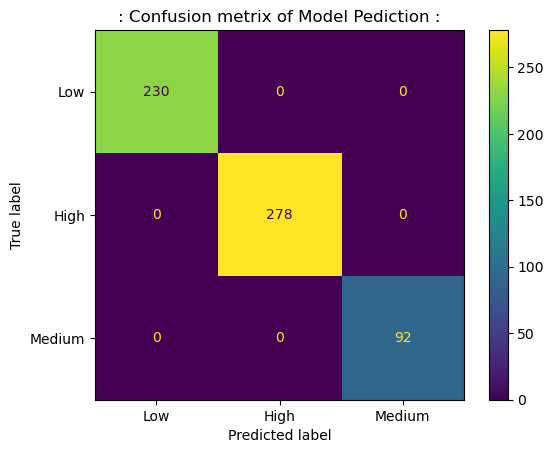

In [94]:
ConfusionMatrixDisplay.from_predictions(y_test, Predicted_Value, display_labels=['Low','High','Medium'])
plt.title(": Confusion metrix of Model Pediction :")
plt.show()

In [96]:
reverse_mapping = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

In [97]:
pred_df = pd.DataFrame(
    Predicted_Value,
    columns=['Perfomance_Prediction']
)

print(pred_df)

     Perfomance_Prediction
0                        0
1                        1
2                        1
3                        1
4                        0
..                     ...
595                      1
596                      1
597                      0
598                      0
599                      1

[600 rows x 1 columns]


In [98]:
pred_df['Perfomance_Prediction'] = pred_df['Perfomance_Prediction'].map(reverse_mapping)

In [99]:
pred_df

,Perfomance_Prediction
0,Low
1,Medium
2,Medium
3,Medium
4,Low
...,...
595,Medium
596,Medium
597,Low
598,Low


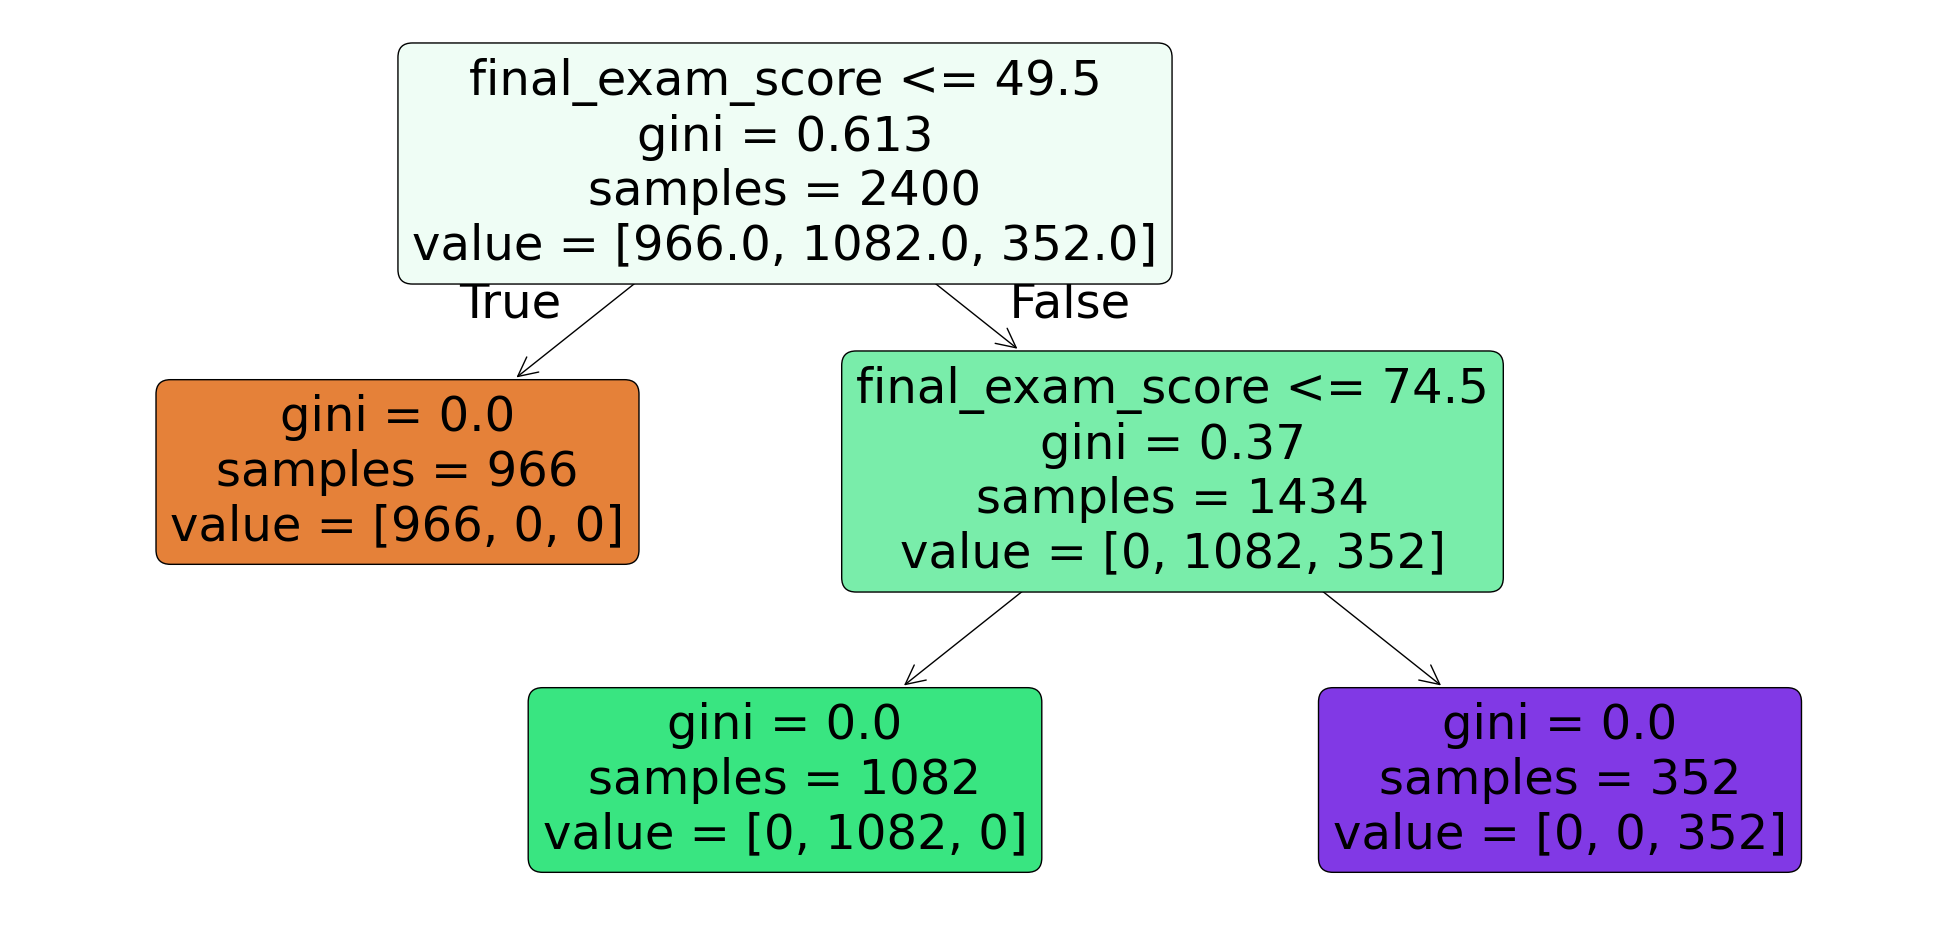

In [102]:
plt.figure(figsize=(25,12))

plot_tree(
    Model_tree,
    max_depth=5,
    filled=True,
    feature_names=X_train.columns,
    rounded=True
)

plt.show()